# Fraud Detection

## Importing libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

## Load data

data source: https://www.kaggle.com/ealaxi/paysim1

In [2]:
df = pd.read_csv('./Datasets/PS_20174392719_1491204439457_log.csv')

## Check dimensions 

In [3]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## Data Cleaning and Preparation

### Check for nulls

In [41]:
df.isnull().sum()

step              1
amount            1
oldbalanceOrg     1
newbalanceOrig    1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
type_TRANSFER     0
dtype: int64

### Check for uniqueness 

In [7]:
df['nameDest'].nunique()

2722362

In [8]:
df['nameOrig'].nunique()

6353307

### Drop some columns 

In [9]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [10]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


## Data Exploration

In [11]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

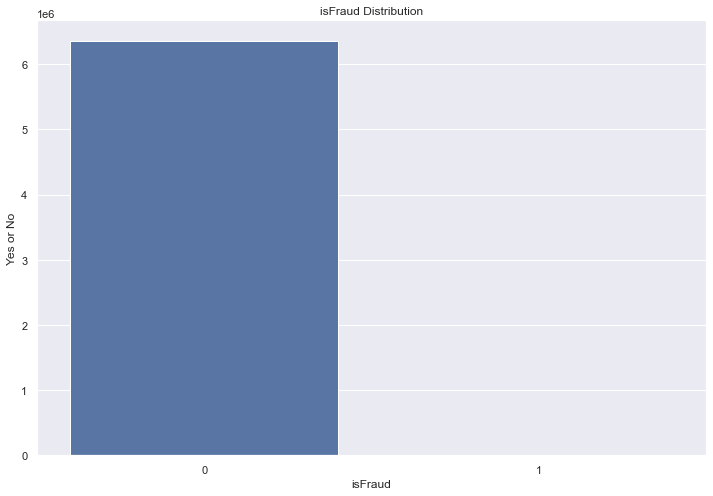

In [12]:
plt.figure(figsize=(12,8))

sns.countplot(x = 'isFraud', data=df)

plt.title('isFraud Distribution')
plt.xlabel('isFraud')
plt.ylabel('Yes or No')

plt.show()

In [13]:
df['isFlaggedFraud'].value_counts()

0    6362604
1         16
Name: isFlaggedFraud, dtype: int64

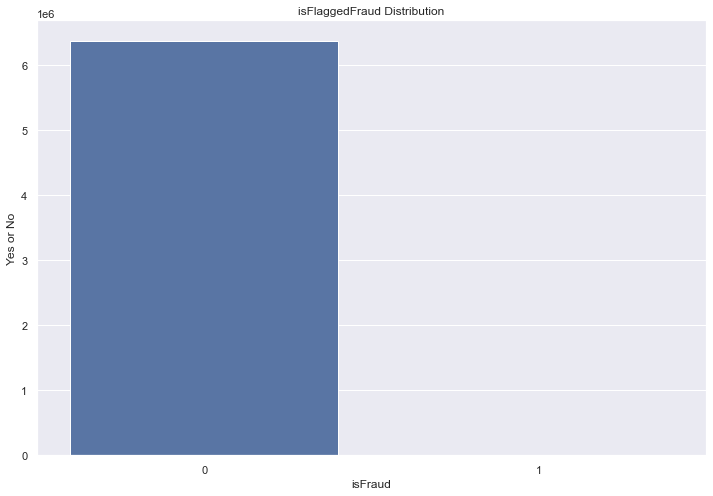

In [14]:
plt.figure(figsize=(12,8))

sns.countplot(x = 'isFlaggedFraud', data=df)

plt.title('isFlaggedFraud Distribution')
plt.xlabel('isFraud')
plt.ylabel('Yes or No')

plt.show()

<Figure size 864x576 with 0 Axes>

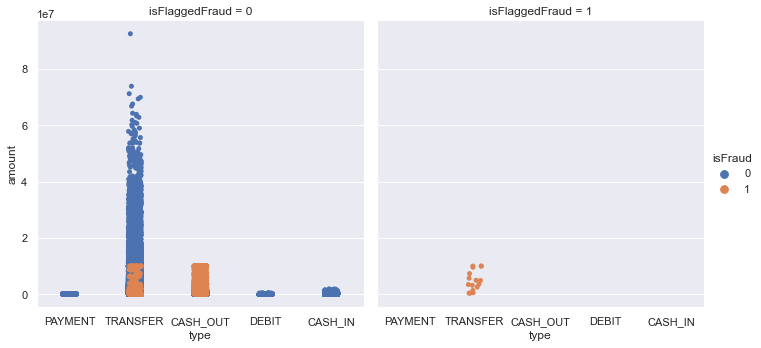

In [15]:
plt.figure(figsize=(12,8))

sns.catplot(x ='type', y ='amount', estimator = sum, hue ='isFraud', col='isFlaggedFraud', data=df)

plt.show()

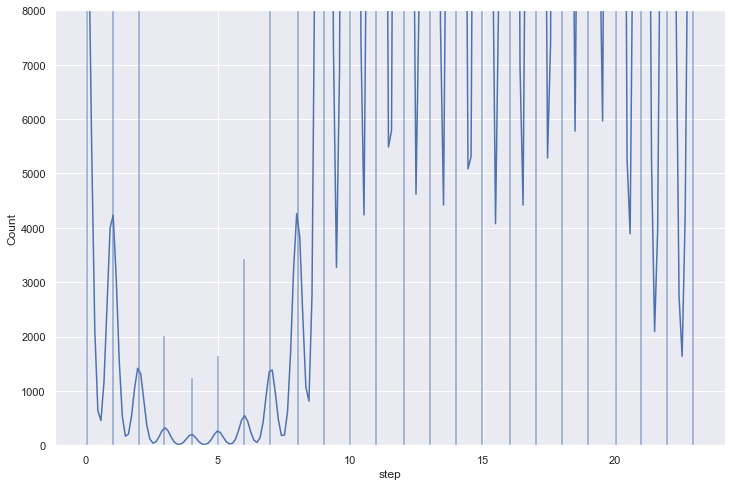

In [17]:
plt.figure(figsize=(12,8))

plt.ylim([0, 8000])
sns.histplot(df['step'], kde=True)

plt.show()

In [16]:
df['step'] = df['step'] % 24

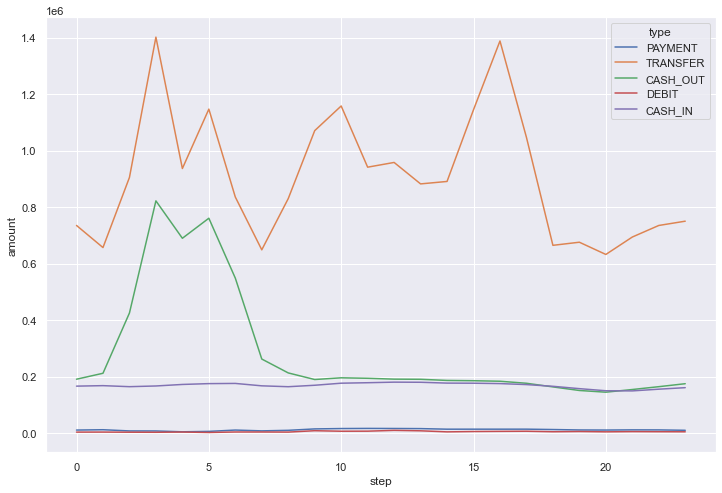

In [19]:
plt.figure(figsize=(12,8))

sns.lineplot(x ='step', y ='amount', hue = 'type', ci =None, estimator='mean', data=df)

plt.show()

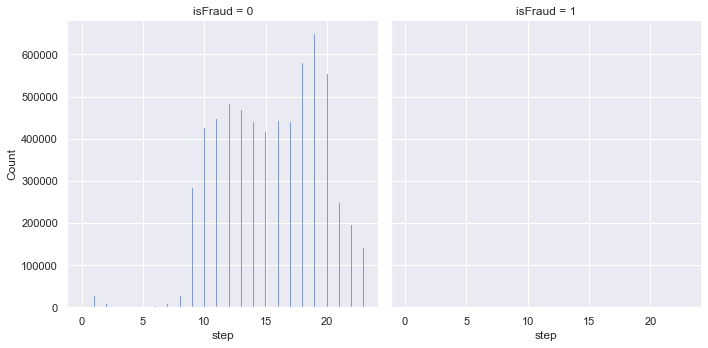

In [21]:
sns.displot(x ='step', col ='isFraud', data=df)

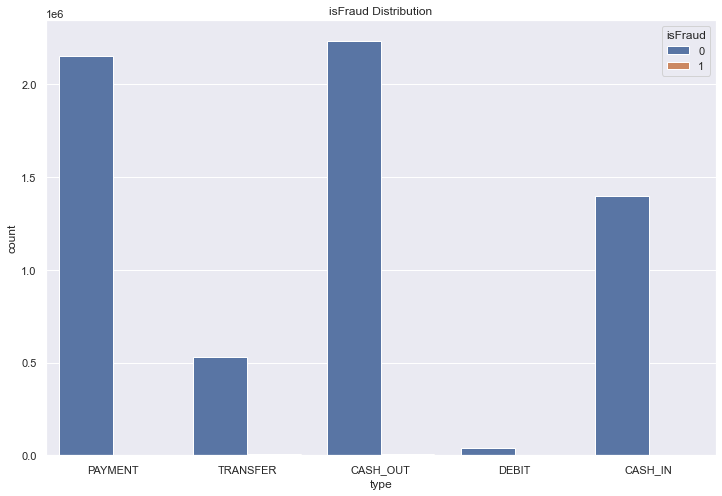

In [23]:
plt.figure(figsize=(12,8))

sns.countplot(x = 'type', hue = 'isFraud', data=df)

plt.title('isFraud Distribution')

plt.show()

In [24]:
df = df.loc[(df.type == 'TRANSFER')|(df.type == 'CASH_OUT')]

In [25]:
df.shape

(2770409, 9)

In [29]:
df.sample(10)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4026929,11,TRANSFER,3143299.35,0.0,0.0,5310750.88,8454050.23,0,0
3317135,12,CASH_OUT,3475.78,0.0,0.0,1698653.53,1702129.31,0,0
2072387,14,TRANSFER,83471.01,0.0,0.0,914486.90,997957.92,0,0
3145285,20,CASH_OUT,21125.43,0.0,0.0,46095.92,67221.35,0,0
3379632,14,CASH_OUT,152852.40,2570.0,0.0,764324.47,917176.87,0,0
4574672,16,CASH_OUT,225025.48,19885.0,0.0,1932541.77,2157567.25,0,0
419086,18,CASH_OUT,290482.51,0.0,0.0,4057234.50,4347717.01,0,0
1415354,19,CASH_OUT,249015.50,0.0,0.0,337601.77,586617.27,0,0
3862316,19,CASH_OUT,108704.87,0.0,0.0,200534.16,309239.03,0,0
955031,20,CASH_OUT,309468.74,0.0,0.0,2116207.11,3373677.73,0,0


### Convert to categorical

In [34]:
df = pd.concat([df, pd.get_dummies(df['type'], prefix='type', drop_first=True)], axis=1)

In [35]:
df.sample(10)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_TRANSFER
1077553,9.0,CASH_OUT,51675.05,0.0,0.0,1932383.73,2190123.41,0.0,0.0,0
4313010,20.0,CASH_OUT,31374.99,20301.0,0.0,2263302.32,2294677.31,0.0,0.0,0
3490924,18.0,TRANSFER,298035.45,0.0,0.0,406839.74,704875.19,0.0,0.0,1
1853565,20.0,CASH_OUT,117174.57,0.0,0.0,222278.20,339452.77,0.0,0.0,0
534129,21.0,CASH_OUT,290346.52,11118.0,0.0,51080.95,341427.47,0.0,0.0,0
4100259,13.0,CASH_OUT,140098.20,477.0,0.0,740592.98,880691.18,0.0,0.0,0
1192933,12.0,CASH_OUT,473849.18,62510.0,0.0,0.00,473849.18,0.0,0.0,0
4466621,12.0,CASH_OUT,246770.94,409.0,0.0,535823.67,782594.62,0.0,0.0,0
696715,12.0,CASH_OUT,161827.25,27670.0,0.0,165598.72,327425.98,0.0,0.0,0
3146466,20.0,CASH_OUT,226284.59,0.0,0.0,709374.73,935659.31,0.0,0.0,0


type_TRANSFER 0 is cash_out, type_TRANSFER 1 is transfer

### Drop more columns 

In [37]:
df.drop(['type', 'isFlaggedFraud'], axis=1, inplace=True)

In [45]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_TRANSFER
2,1.0,181.00,181.0,0.0,0.0,0.00,1.0,1
3,1.0,181.00,181.0,0.0,21182.0,0.00,1.0,0
15,1.0,229133.94,15325.0,0.0,5083.0,51513.44,0.0,0
19,1.0,215310.30,705.0,0.0,22425.0,0.00,0.0,1
24,1.0,311685.89,10835.0,0.0,6267.0,2719172.89,0.0,1


In [43]:
df.dropna(inplace=True)

In [44]:
df['isFraud'].value_counts()

0.0    2762196
1.0       8213
Name: isFraud, dtype: int64

In [46]:
df['origBalanceDiscrepancy'] = df.newbalanceOrig + df.amount - df.oldbalanceOrg

In [47]:
df['destBalanceDiscrepancy'] = df.oldbalanceDest + df.amount - df.newbalanceDest

In [48]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_TRANSFER,origBalanceDiscrepancy,destBalanceDiscrepancy
2,1.0,181.00,181.0,0.0,0.0,0.00,1.0,1,0.00,181.0
3,1.0,181.00,181.0,0.0,21182.0,0.00,1.0,0,0.00,21363.0
15,1.0,229133.94,15325.0,0.0,5083.0,51513.44,0.0,0,213808.94,182703.5
19,1.0,215310.30,705.0,0.0,22425.0,0.00,0.0,1,214605.30,237735.3
24,1.0,311685.89,10835.0,0.0,6267.0,2719172.89,0.0,1,300850.89,-2401220.0


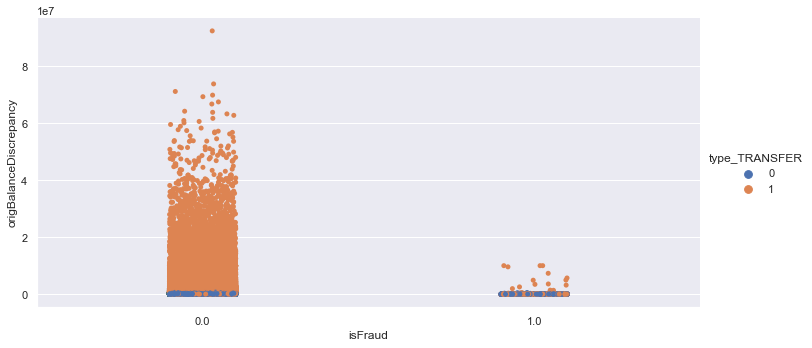

In [51]:
sns.catplot(x ='isFraud', y ='origBalanceDiscrepancy', estimator=sum, hue = 'type_TRANSFER', data=df, aspect=2)

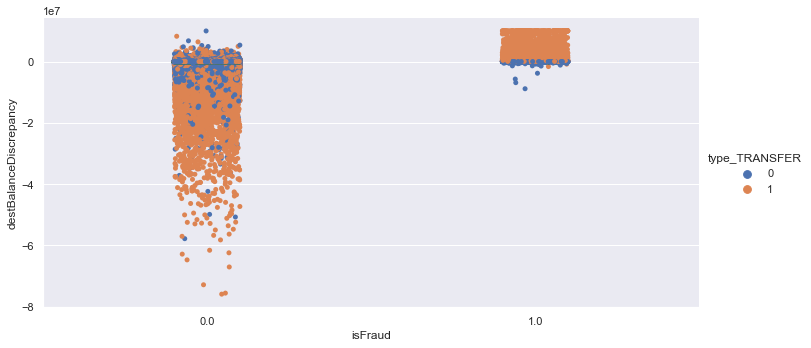

In [52]:
sns.catplot(x ='isFraud', y ='destBalanceDiscrepancy', estimator=sum, hue = 'type_TRANSFER', data=df, aspect=2)

In [54]:
df.to_csv('Datasets/prepared_data.csv', index=False)

## Machine Learning for Fraud Detection

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [55]:
df = pd.read_csv('Datasets/prepared_data.csv')

In [57]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_TRANSFER,origBalanceDiscrepancy,destBalanceDiscrepancy
0,1.0,181.00,181.0,0.0,0.0,0.00,1.0,1,0.00,181.0
1,1.0,181.00,181.0,0.0,21182.0,0.00,1.0,0,0.00,21363.0
2,1.0,229133.94,15325.0,0.0,5083.0,51513.44,0.0,0,213808.94,182703.5
3,1.0,215310.30,705.0,0.0,22425.0,0.00,0.0,1,214605.30,237735.3
4,1.0,311685.89,10835.0,0.0,6267.0,2719172.89,0.0,1,300850.89,-2401220.0


### Train Test Split

In [58]:
X = df.drop(['isFraud'], axis=1)
y = df['isFraud']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [62]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1939286, 9), (831123, 9), (1939286,), (831123,))

### LogisticRegression()

In [66]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [77]:
y_pred_lr = model.predict(X_test)

In [78]:
print('Logistic Regression \n')

print('accuracy: ', accuracy_score(y_test, y_pred_lr))
print('precision: ', precision_score(y_test, y_pred_lr))
print('recall: ', recall_score(y_test, y_pred_lr))

Logistic Regression 

accuracy:  0.9981627268166083
precision:  0.8326848249027238
recall:  0.5029377203290247


### GaussianNB()

In [73]:
from sklearn.naive_bayes import GaussianNB

In [75]:
gauss_model = GaussianNB()

gauss_model.fit(X_train, y_train)

GaussianNB()

In [76]:
y_pred_gauss = gauss_model.predict(X_test)

In [79]:
print('naive_bayes \n')

print('accuracy: ', accuracy_score(y_test, y_pred_gauss))
print('precision: ', precision_score(y_test, y_pred_gauss))
print('recall: ', recall_score(y_test, y_pred_gauss))

naive_bayes 

accuracy:  0.9875072642677437
precision:  0.09854388843314192
recall:  0.3764198981590286


### SVC()

In [80]:
from sklearn.svm import SVC

In [ ]:
svc_model = SVC()

svc_model.fit(X_train, y_train)

In [ ]:
y_pred_svc = svc_model.predict(X_test)

In [ ]:
print('support vector classifier \n')

print('accuracy: ', accuracy_score(y_test, y_pred_svc))
print('precision: ', precision_score(y_test, y_pred_svc))
print('recall: ', recall_score(y_test, y_pred_svc))

### Random Forests()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print('RandomForestClassifier \n')

print('accuracy: ', accuracy_score(y_test, y_pred_rf))
print('precision: ', precision_score(y_test, y_pred_rf))
print('recall: ', recall_score(y_test, y_pred_rf))

## ROC & AUC Curves

In [ ]:
from sklearn.metrics import auc, roc_curve

In [ ]:
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_pred_lr)
auc_logistic = auc(fpr_logistic, tpr_logistic)

print('auc for logistic regression', auc_logistic)

In [ ]:
fpr_gauss, tpr_gauss, _ = roc_curve(y_test, y_pred_gauss)
auc_gauss = auc(fpr_gauss, tpr_gauss)

print('auc for gauss', auc_gauss)

In [ ]:
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_pred_svc)
auc_svc = auc(fpr_svc, tpr_svc)

print('auc for svc', auc_svc)

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print('auc for rf', auc_rf)

In [ ]:
plt.figure(figsize=(12,8))

plt.plot(fpr_logistic, tpr_logistic, color='purple')
plt.plot(fpr_gauss, tpr_gauss, color='blue')
plt.plot(fpr_svc, tpr_svc, color='orange')
plt.plot(fpr_rf, tpr_rf, color='green')

plt.plot([0,1], [0,1], color='navy', linestyle='--')

plt.xlim([-0.01, 1.0])
plt.ylim([-0.01, 1.0])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for ml models')
plt.legend(loc='lower right')